In [13]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from tarnet import Tarnet
import sys
from pathlib import Path
project_root = Path("/home/ducvu0904/Documents/Lab/RERUM")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from utils import seed_everything
from metrics import auuc, auqc, lift, krcc

In [14]:
%time train_df = pd.read_csv(r"../dataset/Hillstrom/Men/train_men.csv")
%time test_df =  pd.read_csv(r"../dataset/Hillstrom/Men/test_men.csv")
%time val_df = pd.read_csv(r"../dataset/Hillstrom/Men/val_men.csv")

CPU times: user 11.5 ms, sys: 3.08 ms, total: 14.5 ms
Wall time: 13.8 ms
CPU times: user 6.01 ms, sys: 0 ns, total: 6.01 ms
Wall time: 5.97 ms
CPU times: user 1.29 ms, sys: 1.02 ms, total: 2.31 ms
Wall time: 2.29 ms


In [15]:
in_features = ['recency', 'history_segment', 'history', 'mens', 'womens',
       'zip_code', 'newbie', "channel"]
label_feature = ['spend']
treatment_feature = ['treatment']

In [16]:
# 1. Định nghĩa danh sách các cột (Bạn hãy điều chỉnh tên cột đúng với dữ liệu của mình)
cat_features = ['zip_code', 'channel', 'history_segment', 'mens', 'womens', "newbie"] # Các biến phân loại (đã LabelEncode)
num_features = ['recency', 'history']     # Các biến số thực (đã Scale)

def prepare_tensors(df):
    """Hàm hỗ trợ chuyển đổi DataFrame thành các Tensor riêng biệt"""
    # Tách dữ liệu
    X_cat = torch.LongTensor(df[cat_features].values)    # Kiểu Long cho Embedding 
    X_num = torch.FloatTensor(df[num_features].values)  # Kiểu Float cho Projection 
    
    # Biến mục tiêu
    t = torch.FloatTensor(df['treatment'].values).unsqueeze(1)
    y = torch.FloatTensor(df['spend'].values).unsqueeze(1) # Lưu ý: Nên là log(1+y) [cite: 191]
    
    return X_cat, X_num, t, y

# 2. Chuyển đổi cho cả 3 tập dữ liệu [cite: 390]
train_cat, train_num, t_train, y_train = prepare_tensors(train_df)
val_cat, val_num, t_val, y_val = prepare_tensors(val_df)
test_cat, test_num, t_test, y_test = prepare_tensors(test_df)

# 3. Khởi tạo TensorDataset với cấu trúc 4 tham số
train_dataset = TensorDataset(train_cat, train_num, t_train, y_train)
val_dataset = TensorDataset(val_cat, val_num, t_val, y_val)
test_dataset = TensorDataset(test_cat, test_num, t_test, y_test)

# 4. Khởi tạo DataLoader [cite: 398, 419]
# Với 5060Ti, batch_size=1024 hoặc 2048 là tối ưu để gradient không quá phẳng
batch_size = 1024 

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 5. Thông tin để khởi tạo Model
cat_dims = [train_df[col].nunique() for col in cat_features]
num_count = len(num_features)

print(f"Mô hình sẽ có {len(cat_dims)} lớp Embedding và {num_count} lớp Projection.")

Mô hình sẽ có 6 lớp Embedding và 2 lớp Projection.


In [17]:
epochs = 150
early_stop_metric = "loss"
patience = 20
print (f" epochs = {epochs}")
print (f" early stop = {early_stop_metric}")
print (f" patience = {patience}")


 epochs = 150
 early stop = loss
 patience = 20


🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/100 | Loss: 10.4599 | Val Loss: 10.1363 | Raw Qini: 0.4958 | EMA Trend: 0.4958 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 2/100 | Loss: 11.0841 | Val Loss: 9.0431 | Raw Qini: 0.6751 | EMA Trend: 0.5227 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 3/100 | Loss: 12.1300 | Val Loss: 9.2833 | Raw Qini: 0.5339 | EMA Trend: 0.5244 | ✓ above trend but not peak (patience: 1/30) | LR: 0.001000
Epoch 4/100 | Loss: 13.7728 | Val Loss: 8.9643 | Raw Qini: 0.6496 | EMA Trend: 0.5432 | ✓ above trend but not peak (patience: 2/30) | LR: 0.001000
Epoch 5/100 | Loss: 12.2998 | Val Loss: 9.5234 | Raw Qini: 0.6125 | EMA Trend: 0.5536 | ✓ above trend but not peak (patience: 3/30) | LR: 0.001000
Epoch 6/100 | Loss: 13.1613 | Val Loss: 8.96

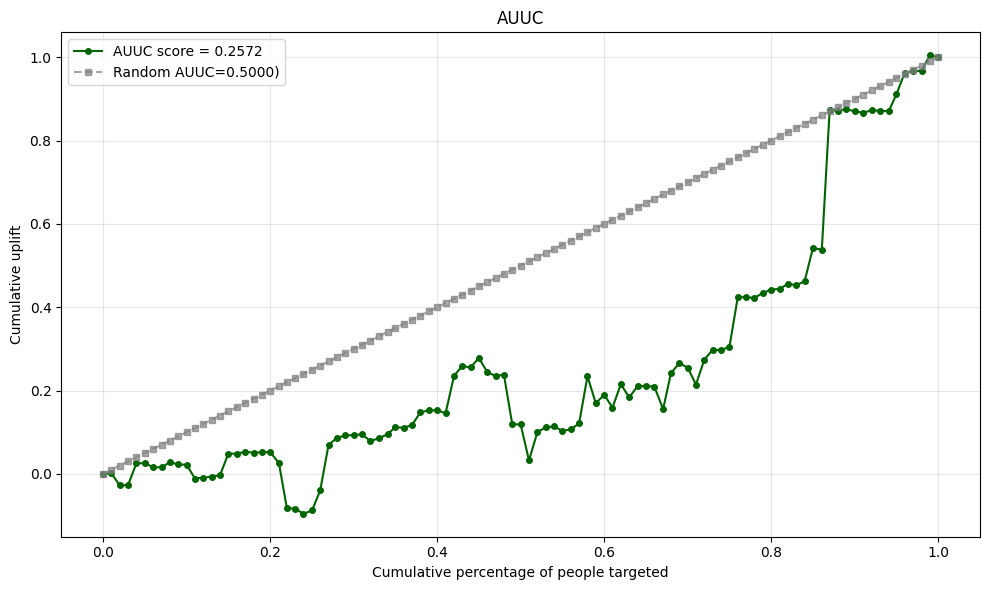

  Done Seed 412312
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/100 | Loss: 9.9413 | Val Loss: 11.0275 | Raw Qini: 0.6665 | EMA Trend: 0.6665 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 2/100 | Loss: 12.2370 | Val Loss: 9.1337 | Raw Qini: 0.5464 | EMA Trend: 0.6485 | (patience: 1/30) | LR: 0.001000
Epoch 3/100 | Loss: 12.0736 | Val Loss: 9.8988 | Raw Qini: 0.5330 | EMA Trend: 0.6311 | (patience: 2/30) | LR: 0.001000
Epoch 4/100 | Loss: 13.0637 | Val Loss: 9.5935 | Raw Qini: 0.5293 | EMA Trend: 0.6159 | (patience: 3/30) | LR: 0.001000
Epoch 5/100 | Loss: 10.4300 | Val Loss: 9.0980 | Raw Qini: 0.5359 | EMA Trend: 0.6039 | (patience: 4/30) | LR: 0.001000
Epoch 6/100 | Loss: 5.6696 | Val Loss: 9.1674 | Raw Qini: 0.5395 | EMA Trend: 0.5942 | (patience: 5/30) | LR: 0.0010

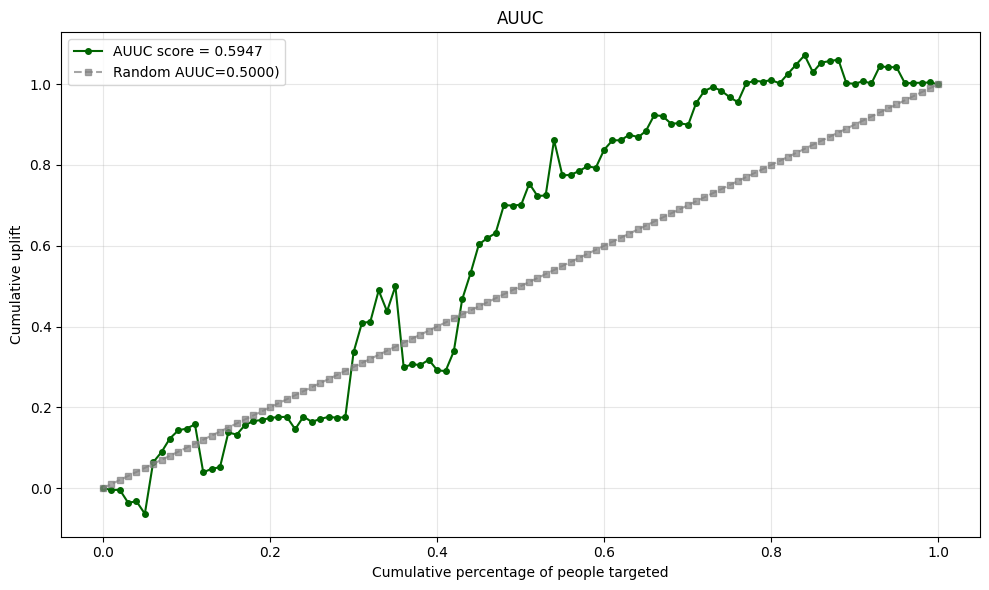

  Done Seed 42
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/100 | Loss: 10.9753 | Val Loss: 11.1456 | Raw Qini: 0.3393 | EMA Trend: 0.3393 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 2/100 | Loss: 12.0160 | Val Loss: 9.1920 | Raw Qini: 0.6456 | EMA Trend: 0.3852 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 3/100 | Loss: 11.0366 | Val Loss: 9.1690 | Raw Qini: 0.7166 | EMA Trend: 0.4349 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 4/100 | Loss: 10.5197 | Val Loss: 9.1904 | Raw Qini: 0.6976 | EMA Trend: 0.4743 | ✓ above trend but not peak (patience: 1/30) | LR: 0.001000
Epoch 5/100 | Loss: 11.5230 | Val Loss: 9.1466 | Raw Qini: 0.7126 | EMA Trend: 0.5101 | ✓ above trend but not peak (patience: 2/30) | LR: 0.001000
Epoch 6/100 | Loss: 6.1670 | Val Loss: 9.1162 |

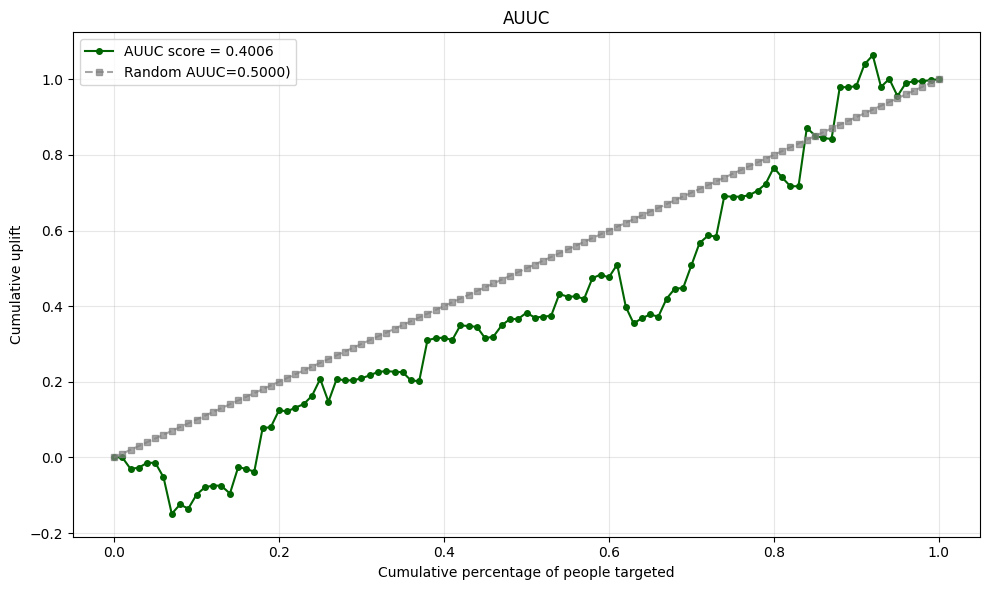

  Done Seed 1874
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/100 | Loss: 13.9849 | Val Loss: 10.1604 | Raw Qini: 0.3095 | EMA Trend: 0.3095 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 2/100 | Loss: 11.5492 | Val Loss: 9.3505 | Raw Qini: 0.4677 | EMA Trend: 0.3332 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 3/100 | Loss: 14.2608 | Val Loss: 10.6669 | Raw Qini: 0.5179 | EMA Trend: 0.3609 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 4/100 | Loss: 11.7191 | Val Loss: 9.0877 | Raw Qini: 0.6374 | EMA Trend: 0.4024 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 5/100 | Loss: 13.2231 | Val Loss: 9.0374 | Raw Qini: 0.7155 | EMA Trend: 0.4493 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 6/100 | Loss: 13.6059 | Val Loss: 9.4760 | Raw Qini: 0.5941 | EMA Trend: 0

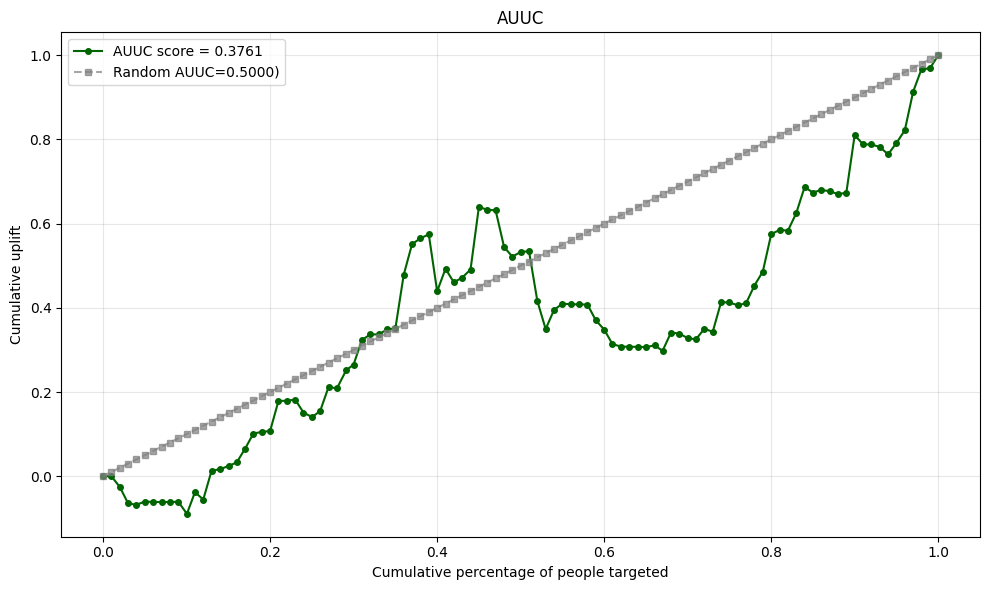

  Done Seed 902745
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/100 | Loss: 17.1896 | Val Loss: 12.9314 | Raw Qini: 0.8275 | EMA Trend: 0.8275 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 2/100 | Loss: 11.8380 | Val Loss: 9.3915 | Raw Qini: 0.5224 | EMA Trend: 0.7818 | (patience: 1/30) | LR: 0.001000
Epoch 3/100 | Loss: 9.6514 | Val Loss: 9.4671 | Raw Qini: 0.4073 | EMA Trend: 0.7256 | (patience: 2/30) | LR: 0.001000
Epoch 4/100 | Loss: 10.8317 | Val Loss: 9.3378 | Raw Qini: 0.4080 | EMA Trend: 0.6780 | (patience: 3/30) | LR: 0.001000
Epoch 5/100 | Loss: 10.5476 | Val Loss: 9.4911 | Raw Qini: 0.5417 | EMA Trend: 0.6575 | (patience: 4/30) | LR: 0.001000
Epoch 6/100 | Loss: 11.4001 | Val Loss: 9.1431 | Raw Qini: 0.5236 | EMA Trend: 0.6374 | (patience: 5/30) | LR: 0.001

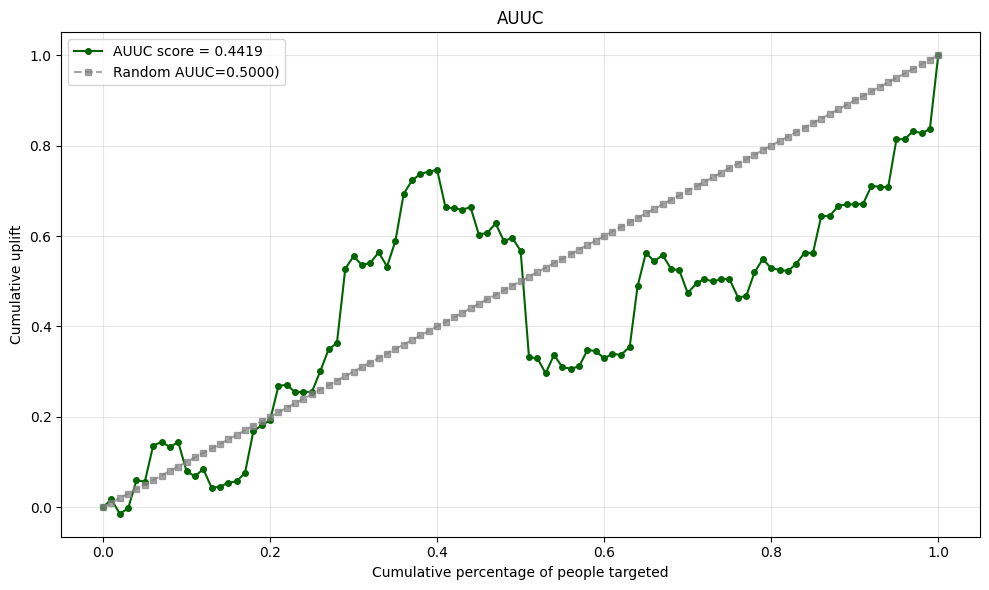

  Done Seed 1
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/100 | Loss: 11.0076 | Val Loss: 11.8619 | Raw Qini: 0.8797 | EMA Trend: 0.8797 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 2/100 | Loss: 13.7903 | Val Loss: 9.2730 | Raw Qini: 0.4915 | EMA Trend: 0.8215 | (patience: 1/30) | LR: 0.001000
Epoch 3/100 | Loss: 12.6627 | Val Loss: 8.9673 | Raw Qini: 0.2846 | EMA Trend: 0.7410 | (patience: 2/30) | LR: 0.001000
Epoch 4/100 | Loss: 11.3084 | Val Loss: 9.0880 | Raw Qini: 0.2664 | EMA Trend: 0.6698 | (patience: 3/30) | LR: 0.001000
Epoch 5/100 | Loss: 11.1252 | Val Loss: 9.0009 | Raw Qini: 0.2937 | EMA Trend: 0.6134 | (patience: 4/30) | LR: 0.001000
Epoch 6/100 | Loss: 11.1494 | Val Loss: 9.0688 | Raw Qini: 0.2572 | EMA Trend: 0.5599 | (patience: 5/30) | LR: 0.001000


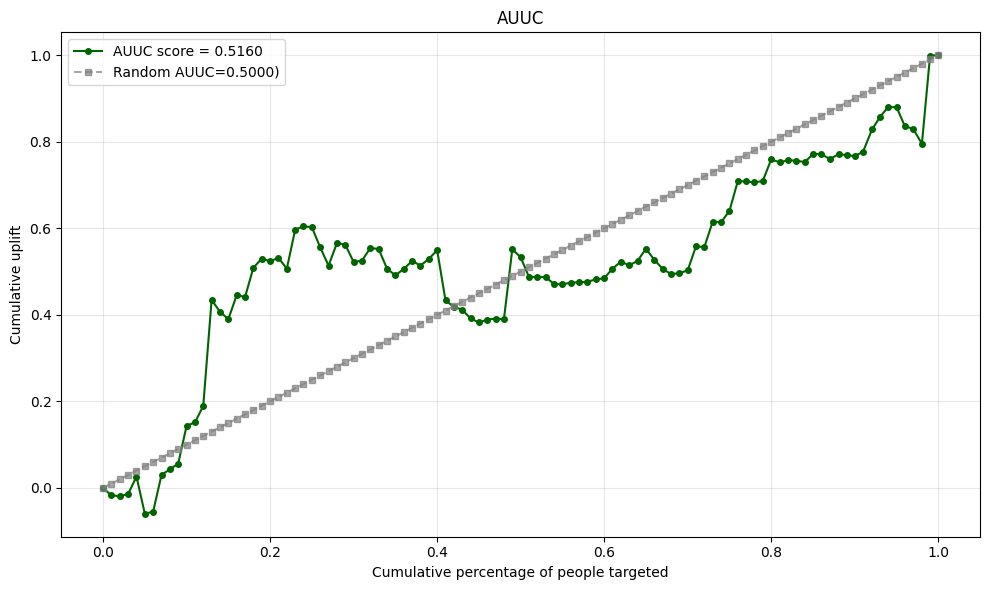

  Done Seed 2
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/100 | Loss: 12.2033 | Val Loss: 10.0632 | Raw Qini: 0.2823 | EMA Trend: 0.2823 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 2/100 | Loss: 12.7164 | Val Loss: 9.1530 | Raw Qini: 0.5698 | EMA Trend: 0.3254 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 3/100 | Loss: 12.4948 | Val Loss: 9.0991 | Raw Qini: 0.8348 | EMA Trend: 0.4018 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 4/100 | Loss: 12.6699 | Val Loss: 9.3560 | Raw Qini: 0.7063 | EMA Trend: 0.4475 | ✓ above trend but not peak (patience: 1/30) | LR: 0.001000
Epoch 5/100 | Loss: 11.3990 | Val Loss: 9.3867 | Raw Qini: 0.6502 | EMA Trend: 0.4779 | ✓ above trend but not peak (patience: 2/30) | LR: 0.001000
Epoch 6/100 | Loss: 5.6806 | Val Loss: 9.1382 | 

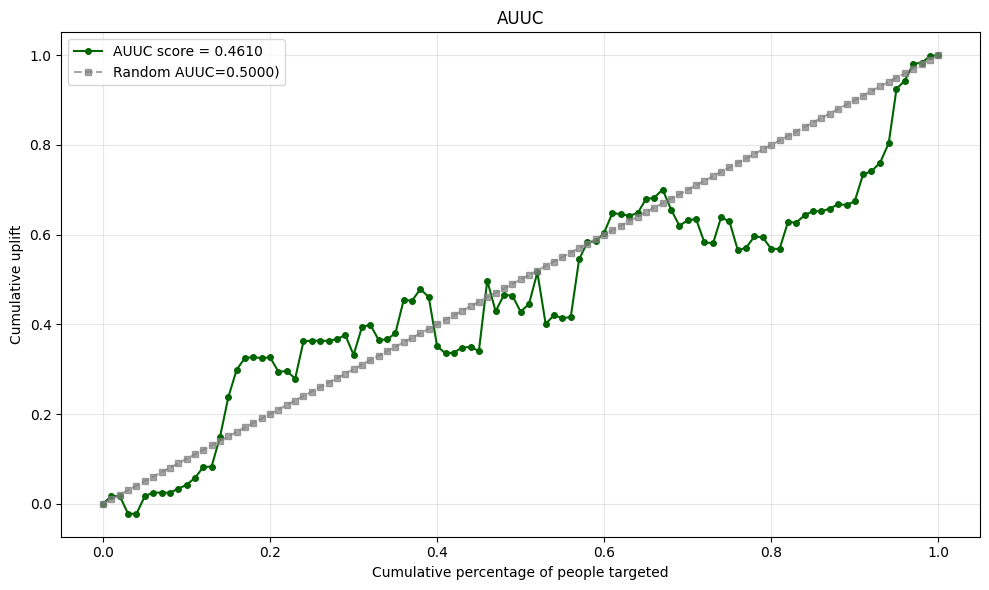

  Done Seed 3
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/100 | Loss: 10.9689 | Val Loss: 10.9292 | Raw Qini: 0.3553 | EMA Trend: 0.3553 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 2/100 | Loss: 11.2847 | Val Loss: 9.1226 | Raw Qini: 0.5154 | EMA Trend: 0.3793 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 3/100 | Loss: 10.9435 | Val Loss: 9.1316 | Raw Qini: 0.6417 | EMA Trend: 0.4186 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 4/100 | Loss: 12.8418 | Val Loss: 9.1884 | Raw Qini: 0.6363 | EMA Trend: 0.4513 | ✓ above trend but not peak (patience: 1/30) | LR: 0.001000
Epoch 5/100 | Loss: 11.9836 | Val Loss: 9.1435 | Raw Qini: 0.5912 | EMA Trend: 0.4723 | ✓ above trend but not peak (patience: 2/30) | LR: 0.001000
Epoch 6/100 | Loss: 12.4830 | Val Loss: 9.7378 |

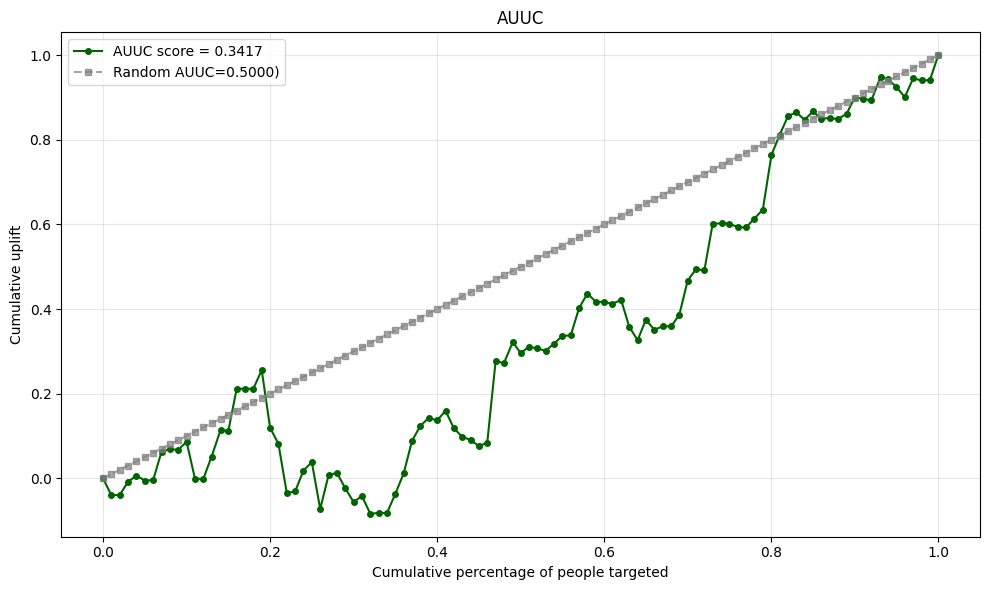

  Done Seed 4
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/100 | Loss: 13.3663 | Val Loss: 9.3384 | Raw Qini: 0.4832 | EMA Trend: 0.4832 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 2/100 | Loss: 12.0619 | Val Loss: 9.7253 | Raw Qini: 0.8810 | EMA Trend: 0.5429 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 3/100 | Loss: 14.3458 | Val Loss: 9.4723 | Raw Qini: 0.7030 | EMA Trend: 0.5669 | ✓ above trend but not peak (patience: 1/30) | LR: 0.001000
Epoch 4/100 | Loss: 13.1108 | Val Loss: 8.9386 | Raw Qini: 0.6974 | EMA Trend: 0.5865 | ✓ above trend but not peak (patience: 2/30) | LR: 0.001000
Epoch 5/100 | Loss: 11.5277 | Val Loss: 9.4064 | Raw Qini: 0.7189 | EMA Trend: 0.6063 | ✓ above trend but not peak (patience: 3/30) | LR: 0.001000
Epoch 6/100 | Loss: 12.6796 | V

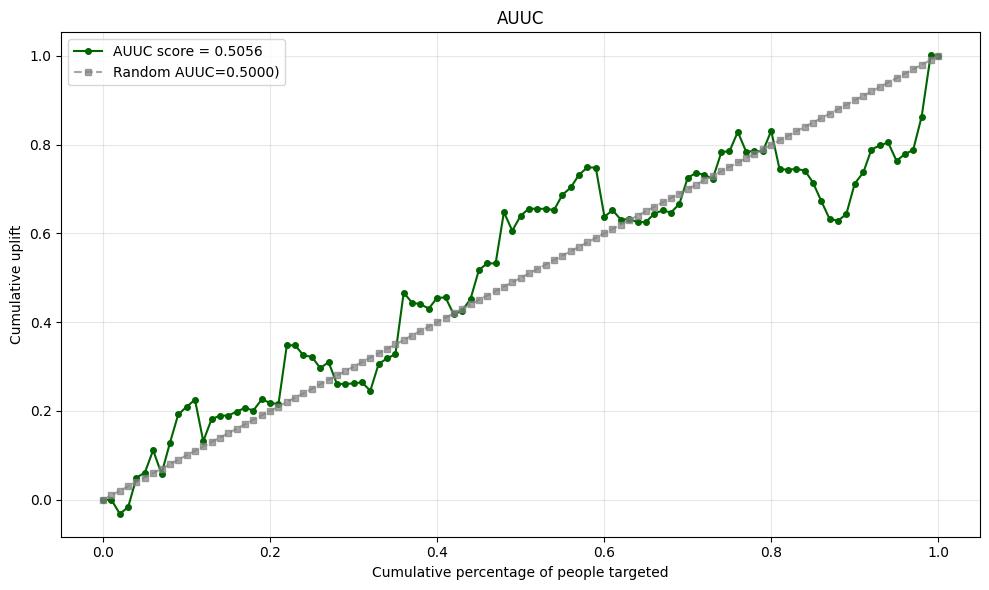

  Done Seed 5
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/100 | Loss: 15.0351 | Val Loss: 11.1272 | Raw Qini: 0.5886 | EMA Trend: 0.5886 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 2/100 | Loss: 13.1273 | Val Loss: 9.1433 | Raw Qini: 0.4590 | EMA Trend: 0.5692 | (patience: 1/30) | LR: 0.001000
Epoch 3/100 | Loss: 11.8320 | Val Loss: 9.1371 | Raw Qini: 0.2946 | EMA Trend: 0.5280 | (patience: 2/30) | LR: 0.001000
Epoch 4/100 | Loss: 12.5857 | Val Loss: 9.1854 | Raw Qini: 0.2526 | EMA Trend: 0.4867 | (patience: 3/30) | LR: 0.001000
Epoch 5/100 | Loss: 11.8628 | Val Loss: 9.4790 | Raw Qini: 0.7646 | EMA Trend: 0.5283 | ⭐ NEW BEST (peak ≥ trend) | LR: 0.001000
Epoch 6/100 | Loss: 10.8847 | Val Loss: 9.3953 | Raw Qini: 0.4189 | EMA Trend: 0.5119 | (patience: 1/30) | LR: 

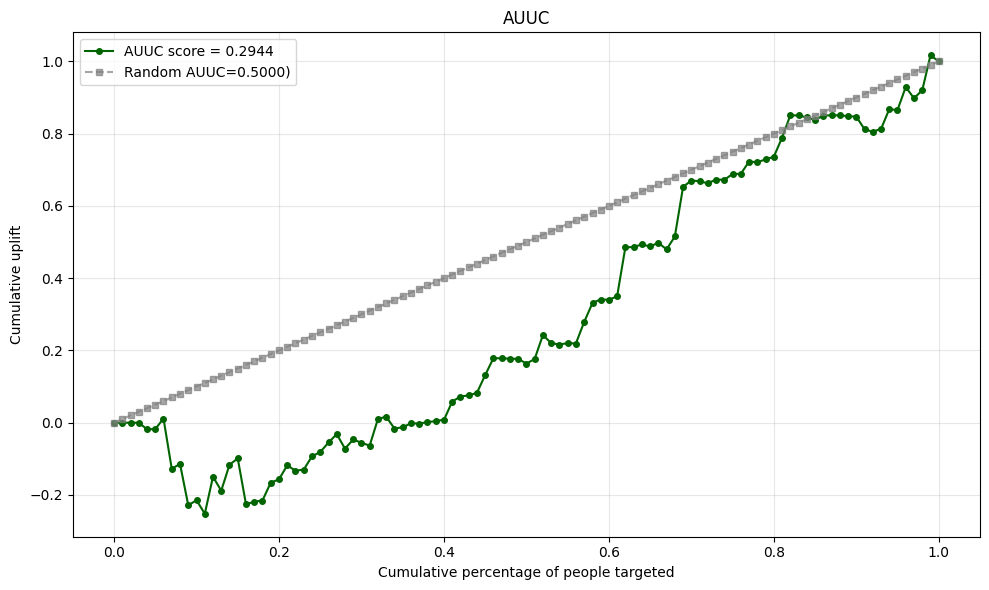

  Done Seed 6

                             PER-SEED DETAILS (TEST SET)                             
  Seed   AUUC   AUQC    Lift    KRCC ATE_Err
412312 0.2572 0.2570  0.1820 -0.0967  1.1005
    42 0.5947 0.5946  0.6591  0.0837  0.2753
  1874 0.4006 0.4013  0.4088 -0.0476  0.2335
902745 0.3761 0.3770  0.5199 -0.0533  0.1532
     1 0.4419 0.4397  1.0865 -0.0021  0.6039
     2 0.5160 0.5128  1.0218 -0.0109  0.0609
     3 0.4610 0.4561  0.6500 -0.0363  1.1179
     4 0.3417 0.3402 -0.1091 -0.0508  0.2791
     5 0.5056 0.5016  0.5125  0.0055  0.6074
     6 0.2944 0.2946 -0.1093 -0.0290  1.0117
                              TEST SUMMARY (MEAN ± STD)                              
-------------------------------------------------------------------------------------
AUUC      : 0.4189 ± 0.1054
AUQC      : 0.4175 ± 0.1045
Lift      : 0.4822 ± 0.4100
KRCC      : -0.0237 ± 0.0480
ATE_Err   : 0.5443 ± 0.4069


In [18]:
# 1. Evaluate selected config on test set (after tuning)
seeds = [412312, 42, 1874, 902745, 1, 2, 3, 4, 5, 6]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
all_runs = []

for SEED in seeds:
    seed_everything(SEED)

    tarnet = Tarnet(
        cate_dims=cat_dims,
        num_count=num_count,
        epochs=30,
        learning_rate=1e-3,
        weight_decay=1e-5,
        patience=30,
        shared_hidden=200,
        outcome_hidden=100,
        outcome_dropout=0.0,
        shared_dropout=0.0,
        early_stop_metric="qini",
        early_stop_start_epoch=0,
    )

    tarnet.fit(train_loader, val_loader)

   # Test prediction
    test_cat_device = test_cat.to(device)
    test_num_device = test_num.to(device)
    y0_pred, y1_pred = tarnet.predict(test_cat_device, test_num_device)

    uplift_pred = (y1_pred - y0_pred).detach().cpu().numpy().flatten()
    y_true = y_test.detach().cpu().numpy().flatten()
    t_true = t_test.detach().cpu().numpy().flatten()

    # ATE error
    ate_pred = uplift_pred.mean()
    ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

    all_runs.append({
        'Seed': SEED,
        'AUUC': auuc(y_true, t_true, uplift_pred, bins=100, plot=True),
        'AUQC': auqc(y_true, t_true, uplift_pred, bins=100, plot=False),
        'Lift': lift(y_true, t_true, uplift_pred, h=0.3),
        'KRCC': krcc(y_true, t_true, uplift_pred, bins=100),
        'ATE_Err': abs(ate_pred - ate_true)
    })
    print(f"  Done Seed {SEED}")

# 3. Aggregate final test metrics
df_results = pd.DataFrame(all_runs)

print("\n" + "=" * 85)
print(f"{'PER-SEED DETAILS (TEST SET)':^85}")
print("=" * 85)
print(df_results.to_string(index=False, formatters={
    'AUUC': '{:,.4f}'.format,
    'AUQC': '{:,.4f}'.format,
    'Lift': '{:,.4f}'.format,
    'KRCC': '{:,.4f}'.format,
    'ATE_Err': '{:,.4f}'.format
}))

mean_res = df_results.drop(columns='Seed').mean()
std_res = df_results.drop(columns='Seed').std()

print("=" * 85)
print(f"{'TEST SUMMARY (MEAN ± STD)':^85}")
print("-" * 85)
for metric in ['AUUC', 'AUQC', 'Lift', 'KRCC', 'ATE_Err']:
    print(f"{metric:<10}: {mean_res[metric]:.4f} ± {std_res[metric]:.4f}")
print("=" * 85)